# MAE Hyperparameter Search

Random search over `LR`, `MASK_RATIO`, and `FFT_LOSS_WEIGHT` on a fraction of the full dataset.

Strategy: each trial trains for `TRIAL_EPOCHS` epochs on `DATASET_FRACTION` of data.
Results are saved after every trial so Colab disconnects don't lose progress.

**Before running:** copy data from Drive to `/tmp` once — it makes each trial ~5x faster:
```python
import shutil
shutil.copytree('/content/drive/MyDrive/SHAD/project/fetal_planes_db', '/tmp/fetal_planes_db')
# repeat for other datasets
```

In [4]:
%matplotlib inline
import math, os, sys, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Subset

PROJECT_ROOT = str(Path('/content').resolve())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from embeddings.vit.train import train_mae

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

ModuleNotFoundError: No module named 'embeddings.vit.model'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load full dataset union

In [7]:
from datasets_adapters.fetal_planes_db.fpd_dataset import FetalPlanesDBDataset
from datasets_adapters.fetal_head_circ.fhc_dataset import FetalHeadCircDataset
from datasets_adapters.focus import FOCUSDataset
from datasets_adapters.abdominal_segmentation import AbdominalSegmentationDataset
from torch.utils.data import ConcatDataset

# Change these to /tmp/... if you copied data locally
DATASET_ROOT  = '/content/drive/MyDrive/SHAD/project/fetal_planes_db'
FHC_DIR       = '/content/drive/MyDrive/SHAD/project/fetal_head_circumference/training_set/training_set'
FHC_CSV       = '/content/drive/MyDrive/SHAD/project/fetal_head_circumference/training_set_pixel_size_and_HC.csv'
FOCUS_ROOT    = '/content/drive/MyDrive/SHAD/project/focus'
ABDOMINAL_ROOT= '/content/drive/MyDrive/SHAD/project/FetalAbdominalSegmentationDataset'

full_dataset = ConcatDataset([
    FetalPlanesDBDataset(root=DATASET_ROOT, images_dir='Images'),
    FetalHeadCircDataset(images_dir=FHC_DIR, csv_file=FHC_CSV, load_annotations=False),
    FOCUSDataset(root=FOCUS_ROOT, split='training', load_masks=False),
    AbdominalSegmentationDataset(root=ABDOMINAL_ROOT, load_masks=False),
])
print(f'Total dataset size: {len(full_dataset)}')

Loaded 12400 images from /content/drive/MyDrive/SHAD/project/fetal_planes_db
Loaded 999 images from /content/drive/MyDrive/SHAD/project/fetal_head_circumference/training_set/training_set
Loaded 200 images from /content/drive/MyDrive/SHAD/project/focus/training
Loaded 1588 samples from /content/drive/MyDrive/SHAD/project/FetalAbdominalSegmentationDataset/ARRAY_FORMAT
Total dataset size: 15187


## 2. Subset configuration

In [8]:
DATASET_FRACTION = 0.25   # fraction of full dataset used per trial
SUBSET_SEED      = 42     # fixed — same subset across all trials for fair comparison

n_total  = len(full_dataset)
n_subset = int(n_total * DATASET_FRACTION)
subset_indices = torch.randperm(
    n_total, generator=torch.Generator().manual_seed(SUBSET_SEED)
)[:n_subset].tolist()
dataset = Subset(full_dataset, subset_indices)
print(f'Using {n_subset}/{n_total} images ({DATASET_FRACTION*100:.0f}%)')

Using 3796/15187 images (25%)


## 3. Fixed architecture + search configuration

Architecture is kept identical to the main run so discovered HPs transfer directly.

In [5]:
# ── Fixed architecture (mirrors main train_mae.ipynb) ───────────────
PATCH_SIZE            = 16
MAX_IMAGE_HEIGHT      = 224
EMBED_DIM             = 512
DEPTH                 = 8
NUM_HEADS             = 8
DECODER_EMBED_DIM     = 384
DECODER_DEPTH         = 6
DECODER_NUM_HEADS     = 8
DECODER_PRED_NUM_LAYERS = 3
MLP_RATIO             = 4.0
NORM_PIX_LOSS         = True
CLIP_PIXEL_PRED       = False
L1_RATIO              = 0.9   # fixed — not part of this search

# ── Fixed training knobs ────────────────────────────────────────────
BATCH_SIZE    = 128
WEIGHT_DECAY  = 0.05
VAL_SPLIT     = 0.1
NUM_WORKERS   = 8
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Search knobs ────────────────────────────────────────────────────
N_TRIALS      = 20          # total random trials
TRIAL_EPOCHS  = 30          # epochs per trial (~5 min each on A100 with this subset)
WARMUP_EPOCHS = 5           # shorter warmup appropriate for TRIAL_EPOCHS
SEARCH_SEED   = 0

# HP search ranges
# LR: log-uniform in [5e-5, 5e-4]
LR_LOG_LOW,  LR_LOG_HIGH  = math.log10(5e-5), math.log10(5e-4)
# MASK_RATIO: uniform in [0.45, 0.75]
MASK_LOW,    MASK_HIGH    = 0.45, 0.75
# FFT_LOSS_WEIGHT: log-uniform in [0.02, 0.5]; 0 included via explicit baseline
FFT_LOG_LOW, FFT_LOG_HIGH = math.log10(0.02), math.log10(0.5)

# Output directory
RESULTS_DIR = os.path.join(
    '/content/drive/MyDrive/SHAD/project/checkpoints/mae/hparam_search'
)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results will be saved to: {RESULTS_DIR}')
print(f'Device: {DEVICE}')
RESULTS_PATH = os.path.join(RESULTS_DIR, 'search_results.json')

Results will be saved to: /content/drive/MyDrive/SHAD/project/checkpoints/mae/hparam_search
Device: cpu


## 4. Random search

Trial 0 is the **current baseline** (your existing config). Trials 1–N are random draws.
Results are written to `search_results.json` after every trial.

In [ ]:
RESULTS_PATH = os.path.join(RESULTS_DIR, 'search_results.json')

# Resume from a previous run if the file already exists
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        results = json.load(f)
    print(f'Resuming — {len(results)} trials already done.')
else:
    results = []

completed_trials = {r['trial'] for r in results}

rng = np.random.RandomState(SEARCH_SEED)

# Pre-generate all HP draws so resuming gives the same sequence
all_hps = []
# Trial 0: baseline = current main config
all_hps.append({
    'lr': 1.5e-4,
    'mask_ratio': 0.75,
    'fft_loss_weight': 0.1,
    'note': 'baseline (current config)',
})
# Trials 1..N_TRIALS-1: random draws
for _ in range(N_TRIALS - 1):
    all_hps.append({
        'lr':              float(10 ** rng.uniform(LR_LOG_LOW,  LR_LOG_HIGH)),
        'mask_ratio':      float(rng.uniform(MASK_LOW, MASK_HIGH)),
        'fft_loss_weight': float(10 ** rng.uniform(FFT_LOG_LOW, FFT_LOG_HIGH)),
        'note': 'random',
    })

print(f'Running {N_TRIALS} trials × {TRIAL_EPOCHS} epochs on {len(dataset)} images.')
print(f'Estimated time: ~{N_TRIALS * TRIAL_EPOCHS * len(dataset) / 128 / 4 / 60:.0f} min on A100\n')
print('Ranking metric: val_ref_mse (pure normalized per-patch MSE, loss-weight independent)\n')

for trial_idx, hp in enumerate(all_hps):
    if trial_idx in completed_trials:
        print(f'Trial {trial_idx:02d} already done, skipping.')
        continue

    lr              = hp['lr']
    mask_ratio      = hp['mask_ratio']
    fft_loss_weight = hp['fft_loss_weight']

    print(f"{'='*64}")
    print(f"Trial {trial_idx:02d}/{N_TRIALS-1}  [{hp.get('note', 'random')}]")
    print(f"  lr={lr:.2e}  mask_ratio={mask_ratio:.3f}  fft_loss_weight={fft_loss_weight:.3f}")
    print(f"{'='*64}")

    t_start = time.time()
    try:
        _, history = train_mae(
            dataset,
            # architecture
            max_image_height        = MAX_IMAGE_HEIGHT,
            patch_size              = PATCH_SIZE,
            embed_dim               = EMBED_DIM,
            depth                   = DEPTH,
            num_heads               = NUM_HEADS,
            decoder_embed_dim       = DECODER_EMBED_DIM,
            decoder_depth           = DECODER_DEPTH,
            decoder_num_heads       = DECODER_NUM_HEADS,
            decoder_pred_num_layers = DECODER_PRED_NUM_LAYERS,
            mlp_ratio               = MLP_RATIO,
            norm_pix_loss           = NORM_PIX_LOSS,
            clip_pixel_pred         = CLIP_PIXEL_PRED,
            # loss
            l1_loss_weight          = L1_RATIO,
            l2_loss_weight          = 1 - L1_RATIO,
            fft_loss_weight         = fft_loss_weight,
            # training
            epochs                  = TRIAL_EPOCHS,
            batch_size              = BATCH_SIZE,
            lr                      = lr,
            weight_decay            = WEIGHT_DECAY,
            warmup_epochs           = WARMUP_EPOCHS,
            min_lr                  = lr * 0.01,
            mask_ratio              = mask_ratio,
            val_split               = VAL_SPLIT,
            num_workers             = NUM_WORKERS,
            device                  = DEVICE,
            use_amp                 = True,
        )
        elapsed = time.time() - t_start

        # val_ref_mse is the fair comparison metric: pure normalized MSE,
        # independent of l1/fft weights. val_loss is also stored for reference.
        best_ref  = float(min(history['val_ref_mse']))
        final_ref = float(history['val_ref_mse'][-1])
        best_val  = float(min(history['val_loss']))

        print(f'  done: best_ref_mse={best_ref:.4f}  best_val_loss={best_val:.4f}  ({elapsed/60:.1f} min)')

        result = {
            'trial':                trial_idx,
            'note':                 hp.get('note', 'random'),
            'lr':                   lr,
            'mask_ratio':           mask_ratio,
            'fft_loss_weight':      fft_loss_weight,
            # primary ranking metric
            'best_val_ref_mse':     best_ref,
            'final_val_ref_mse':    final_ref,
            'val_ref_mse_history':  [float(v) for v in history['val_ref_mse']],
            # total loss (informational only — not used for ranking)
            'best_val_loss':        best_val,
            'val_loss_history':     [float(v) for v in history['val_loss']],
            'train_loss_history':   [float(v) for v in history['train_loss']],
            'elapsed_seconds':      elapsed,
        }
    except Exception as e:
        elapsed = time.time() - t_start
        print(f'  FAILED: {e}')
        result = {
            'trial':           trial_idx,
            'note':            hp.get('note', 'random'),
            'lr':              lr,
            'mask_ratio':      mask_ratio,
            'fft_loss_weight': fft_loss_weight,
            'error':           str(e),
            'elapsed_seconds': elapsed,
        }

    results.append(result)
    with open(RESULTS_PATH, 'w') as f:
        json.dump(results, f, indent=2)

print(f'\nSearch complete. Results: {RESULTS_PATH}')

Running 20 trials × 30 epochs on 3796 images.
Estimated time: ~74 min on A100

Ranking metric: val_ref_mse (pure normalized per-patch MSE, loss-weight independent)

Trial 00/19  [baseline (current config)]
  lr=1.50e-04  mask_ratio=0.750  fft_loss_weight=0.100
Training on: cuda
Train: 3417 samples | Val: 379 samples


/content/embeddings/vit/train.py:1094: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if _use_amp else None


Model parameters: 36,591,360 total | 25,352,192 encoder
Mixed precision (AMP) enabled.


Epoch   0/30 | train_loss=0.7282 | val_loss=0.7019 | val_ref_mse=0.8662 | lr=3.00e-05


Epoch   1/30 | train_loss=0.7152 | val_loss=0.7005 | val_ref_mse=0.8652 | lr=6.00e-05


...

Epoch   7/30 | train_loss=0.6617 | val_loss=0.6388 | val_ref_mse=0.7909 | lr=2.31e-04


Epoch   8/30 | train_loss=0.6520 | val_loss=0.6372 | val_ref_mse=0.7816 | lr=2.26e-04


Epoch   9/30 | train_loss=0.6367 | val_loss=0.6202 | val_ref_mse=0.7580 | lr=2.20e-04


Epoch  10/30 | train_loss=0.6238 | val_loss=0.6092 | val_ref_mse=0.7436 | lr=2.12e-04


Epoch 11 [train]:   0%|          | 0/26 [00:00<?, ?it/s]

## 5. Results

Run this cell independently to reload results after a Colab disconnect.

In [6]:
with open(RESULTS_PATH) as f:
    results = json.load(f)

df = pd.DataFrame([r for r in results if 'best_val_ref_mse' in r])
df = df.sort_values('best_val_ref_mse').reset_index(drop=True)

print(f'Completed trials: {len(df)}')
print()
print('Sorted by val_ref_mse (pure normalized MSE — comparable across all configs)')
print()
print(df[['trial', 'note', 'lr', 'mask_ratio', 'fft_loss_weight',
          'best_val_ref_mse', 'best_val_loss']]
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best = df.iloc[0]
print(f'\nBest trial: {int(best.trial)} ({best.note})')
print(f'  LR              = {best.lr:.2e}')
print(f'  MASK_RATIO      = {best.mask_ratio:.3f}')
print(f'  FFT_LOSS_WEIGHT = {best.fft_loss_weight:.3f}')
print(f'  best_val_ref_mse = {best.best_val_ref_mse:.4f}  (ranking metric)')
print(f'  best_val_loss    = {best.best_val_loss:.4f}  (total training loss, for reference only)')

Completed trials: 19

Sorted by val_ref_mse (pure normalized MSE — comparable across all configs)

 trial                      note     lr  mask_ratio  fft_loss_weight  best_val_ref_mse  best_val_loss
    15                    random 0.0002      0.4681           0.1711            0.6371         0.5709
    12                    random 0.0002      0.4556           0.1460            0.6554         0.5782
    16                    random 0.0002      0.5131           0.0303            0.6565         0.5554
    10                    random 0.0004      0.6066           0.0760            0.6572         0.5616
    14                    random 0.0002      0.5579           0.0817            0.6659         0.5699
     8                    random 0.0003      0.5884           0.2467            0.6670         0.6019
     2                    random 0.0002      0.5771           0.1599            0.6709         0.5882
    17                    random 0.0001      0.5591           0.1254            0.696

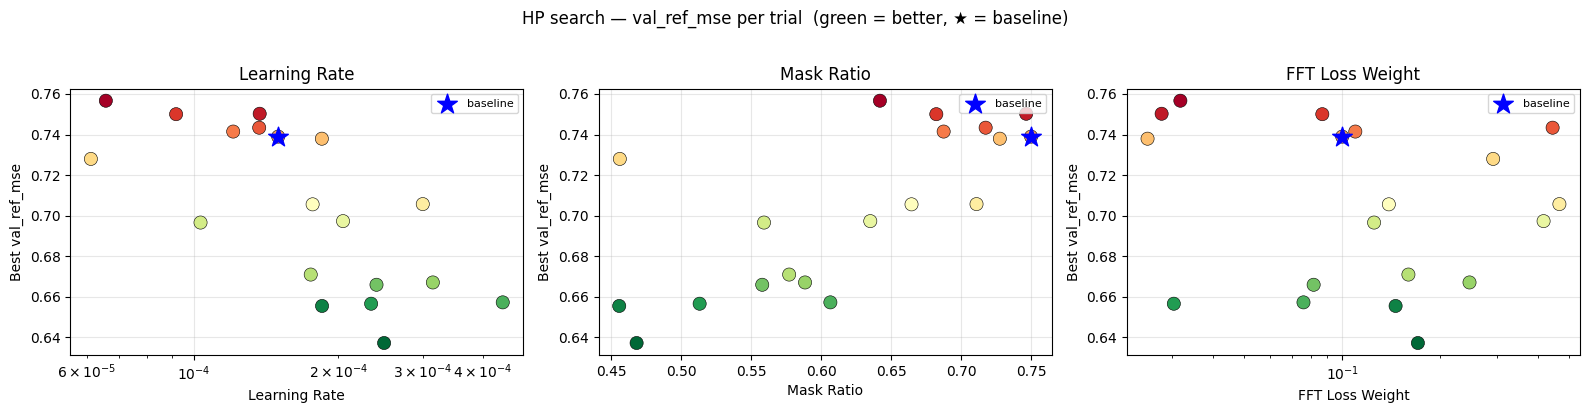

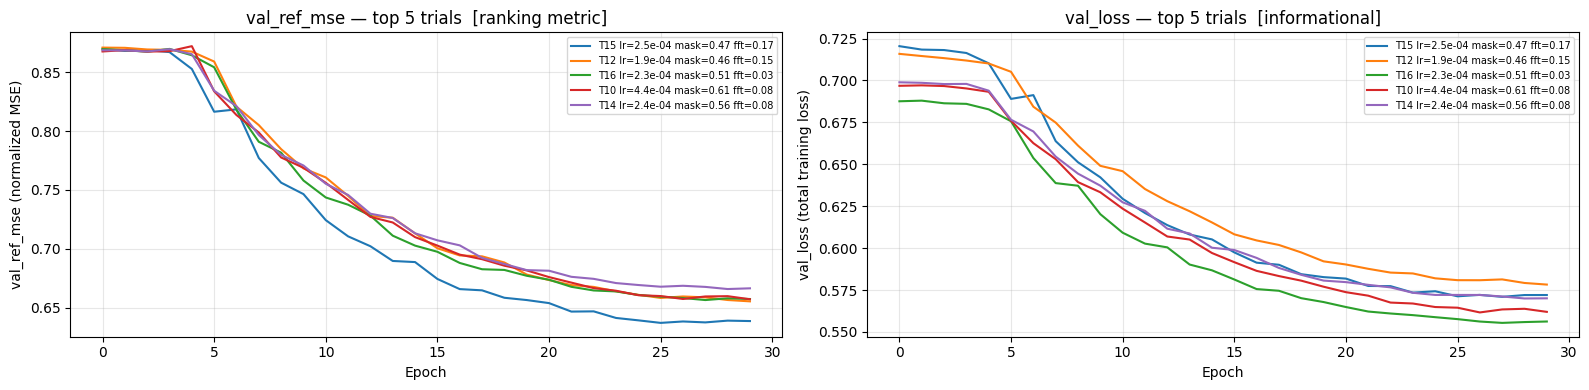

In [7]:
rank_order = np.arange(len(df))  # df already sorted best→worst by val_ref_mse

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, label, log_scale in zip(
    axes,
    ['lr',           'mask_ratio',  'fft_loss_weight'],
    ['Learning Rate', 'Mask Ratio',  'FFT Loss Weight'],
    [True,            False,          True],
):
    ax.scatter(
        df[col], df['best_val_ref_mse'],
        c=rank_order, cmap='RdYlGn_r', s=90, zorder=3, edgecolors='k', linewidths=0.4,
    )
    base = df[df['note'] == 'baseline (current config)']
    if len(base):
        ax.scatter(base[col], base['best_val_ref_mse'], marker='*', s=220,
                   color='blue', zorder=5, label='baseline')
        ax.legend(fontsize=8)
    if log_scale:
        ax.set_xscale('log')
    ax.set_xlabel(label)
    ax.set_ylabel('Best val_ref_mse')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

plt.suptitle('HP search — val_ref_mse per trial  (green = better, ★ = baseline)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'search_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

# val_ref_mse curves: top 5
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
top5 = df.head(5)

for ax, hist_key, ylabel, title in zip(
    axes,
    ['val_ref_mse_history', 'val_loss_history'],
    ['val_ref_mse (normalized MSE)', 'val_loss (total training loss)'],
    ['val_ref_mse — top 5 trials  [ranking metric]',
     'val_loss — top 5 trials  [informational]'],
):
    for _, row in top5.iterrows():
        lbl = (f"T{int(row.trial)} lr={row.lr:.1e} "
               f"mask={row.mask_ratio:.2f} fft={row.fft_loss_weight:.2f}")
        ax.plot(row[hist_key], label=lbl)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'search_curves.png'), dpi=150, bbox_inches='tight')
plt.show()